Using device: cuda

--- Table 2 Stat: The model has 35,505,984 trainable parameters ---

Starting Training...
Epoch: 01 | Time: 11m 4s
	Train Loss: 5.417 | Val. Loss: 6.213
Epoch: 02 | Time: 11m 12s
	Train Loss: 4.849 | Val. Loss: 6.018
Epoch: 03 | Time: 11m 14s
	Train Loss: 4.466 | Val. Loss: 6.023
Epoch: 04 | Time: 11m 15s
	Train Loss: 4.164 | Val. Loss: 5.970
Epoch: 05 | Time: 11m 13s
	Train Loss: 3.912 | Val. Loss: 6.056
Epoch: 06 | Time: 11m 13s
	Train Loss: 3.691 | Val. Loss: 6.025
Epoch: 07 | Time: 11m 14s
	Train Loss: 3.498 | Val. Loss: 6.121
Epoch: 08 | Time: 11m 15s
	Train Loss: 3.349 | Val. Loss: 6.174
Epoch: 09 | Time: 11m 15s
	Train Loss: 3.216 | Val. Loss: 6.227
Epoch: 10 | Time: 11m 15s
	Train Loss: 3.109 | Val. Loss: 6.241

Saved loss_curve.png for Figure 1.
Saved best_model.pt (Your finished AI brain!).


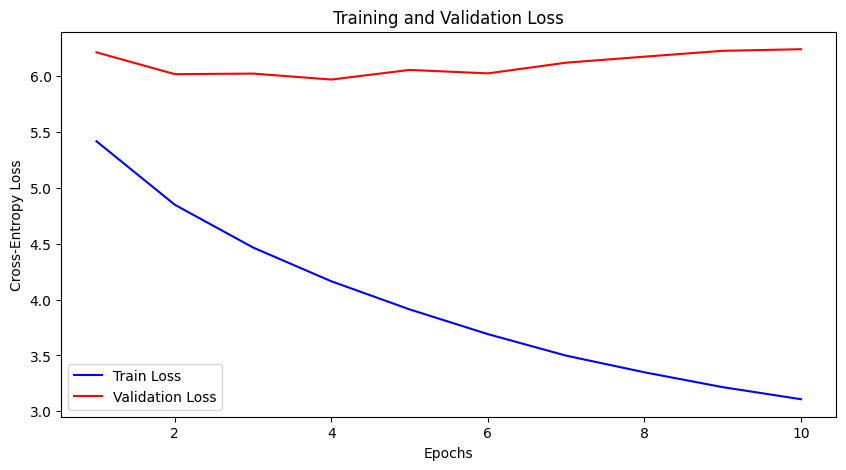

In [3]:
!pip install sentencepiece torch matplotlib pandas -q

import time, random, torch, pandas as pd, sentencepiece as spm, matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VOCAB_SIZE, EMB_DIM, HID_DIM, N_LAYERS = 8000, 256, 512, 2
DROPOUT, BATCH_SIZE, EPOCHS, CLIP = 0.3, 64, 10, 1.0
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

sp = spm.SentencePieceProcessor(model_file="ur_sp.model")

class UQADataset(Dataset):
    def __init__(self, file_path):
        df = pd.read_csv(file_path, sep='\t', header=None, names=['src', 'tgt'], encoding='utf-8', encoding_errors='ignore')
        self.src, self.tgt = df['src'].tolist(), df['tgt'].tolist()

    def __len__(self): return len(self.src)

    def __getitem__(self, idx):
        src_tok = [BOS_IDX] + sp.encode(self.src[idx]) + [EOS_IDX]
        tgt_tok = [BOS_IDX] + sp.encode(self.tgt[idx]) + [EOS_IDX]
        return torch.tensor(src_tok), torch.tensor(tgt_tok)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    return src_pad, tgt_pad

train_loader = DataLoader(UQADataset("train.tsv"), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(UQADataset("valid.tsv"), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMB_DIM)
        self.rnn = nn.LSTM(EMB_DIM, HID_DIM, num_layers=N_LAYERS, bidirectional=True, dropout=DROPOUT, batch_first=True)
        self.fc_hidden = nn.Linear(HID_DIM * 2, HID_DIM)
        self.fc_cell = nn.Linear(HID_DIM * 2, HID_DIM)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, src):
        enc_out, (hidden, cell) = self.rnn(self.dropout(self.embedding(src)))
        hidden = torch.tanh(self.fc_hidden(torch.cat((hidden[0::2], hidden[1::2]), dim=2)))
        cell = torch.tanh(self.fc_cell(torch.cat((cell[0::2], cell[1::2]), dim=2)))
        return enc_out, hidden, cell

class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Linear((HID_DIM * 2) + HID_DIM, HID_DIM)
        self.v = nn.Linear(HID_DIM, 1, bias=False)

    def forward(self, hidden, enc_out):
        hidden = hidden.unsqueeze(1).repeat(1, enc_out.shape[1], 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, enc_out), dim=2)))
        return torch.softmax(self.v(energy).squeeze(2), dim=1)

class Decoder(nn.Module):
    def __init__(self, attention):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(VOCAB_SIZE, EMB_DIM)
        self.rnn = nn.LSTM(EMB_DIM + (HID_DIM * 2), HID_DIM, num_layers=N_LAYERS, dropout=DROPOUT, batch_first=True)
        self.fc_out = nn.Linear((HID_DIM * 2) + HID_DIM + EMB_DIM, VOCAB_SIZE)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, input, hidden, cell, enc_out):
        embedded = self.dropout(self.embedding(input.unsqueeze(1)))
        context = torch.bmm(self.attention(hidden[-1], enc_out).unsqueeze(1), enc_out)
        output, (hidden, cell) = self.rnn(torch.cat((embedded, context), dim=2), (hidden, cell))
        pred = self.fc_out(torch.cat((output.squeeze(1), context.squeeze(1), embedded.squeeze(1)), dim=1))
        return pred, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder

    def forward(self, src, tgt, tf_ratio=0.5):
        batch_size, tgt_len = src.shape[0], tgt.shape[1]
        outputs = torch.zeros(batch_size, tgt_len, VOCAB_SIZE).to(device)
        enc_out, hidden, cell = self.encoder(src)
        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell, enc_out)
            outputs[:, t, :] = output
            input = tgt[:, t] if random.random() < tf_ratio else output.argmax(1)
        return outputs

model = Seq2Seq(Encoder(), Decoder(BahdanauAttention())).to(device)
print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def run_epoch(model, iterator, optimizer, criterion, clip, is_train=True):
    model.train() if is_train else model.eval()
    epoch_loss = 0
    with torch.set_grad_enabled(is_train):
        for src, tgt in iterator:
            src, tgt = src.to(device), tgt.to(device)
            if is_train: optimizer.zero_grad()
            output = model(src, tgt, tf_ratio=0.5 if is_train else 0)
            loss = criterion(output[:, 1:].reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

train_losses, valid_losses, best_valid_loss = [], [], float('inf')

for epoch in range(EPOCHS):
    start = time.time()
    train_loss = run_epoch(model, train_loader, optimizer, criterion, CLIP, is_train=True)
    valid_loss = run_epoch(model, valid_loader, optimizer, criterion, CLIP, is_train=False)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch {epoch+1:02} | Time: {int(time.time()-start)}s | Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")

plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS+1), valid_losses, label='Validation Loss', color='red')
plt.legend()
plt.savefig('loss_curve.png')